# Veri Madenciliği Ödevi 2

Bu çalışmada veri madenciliği sürecinin temel aşamaları Python kullanılarak uygulanmıştır. Süreç veri temizleme, eksik veri analizi, aykırı değer tespiti, görselleştirme ve lineer regresyon modelini kapsamaktadır.


**Kütüphaneler**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Veri yükleme**

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


**Veri inceleme**

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


**Eksik veri**

In [4]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


**Eksik Veri Doldurma**

In [6]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

**Aykırı değer (IQR)**

In [8]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5*IQR) & (df[column] <= Q3 + 1.5*IQR)]

for col in ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]:
    df = remove_outliers(df, col)

**Görselleştirme**

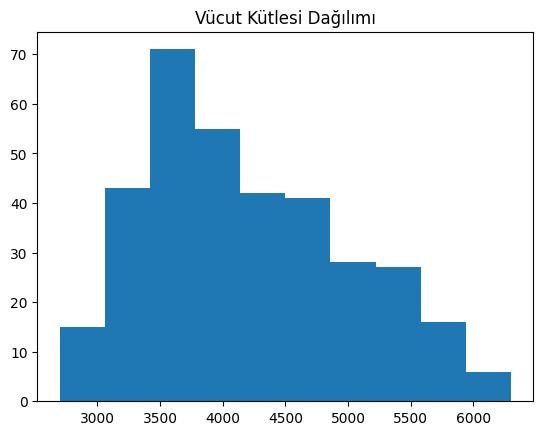

In [9]:
plt.figure()
plt.hist(df["body_mass_g"])
plt.title("Vücut Kütlesi Dağılımı")
plt.show()

**Korelasyon**

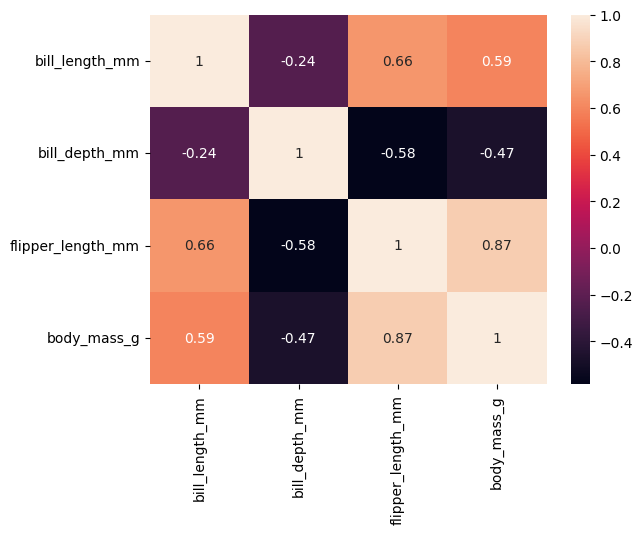

In [10]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.show()

**Model**

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]]
y = df["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 312.2827761182122
R2: 0.7506787160058195


**if ve while**

In [12]:
if r2_score(y_test, y_pred) > 0.7:
    print("Model iyi")
else:
    print("Model geliştirilmeli")

Model iyi


In [13]:
i = 1
toplam = 0

while i <= 5:
    toplam += i
    i += 1

print("Toplam:", toplam)

Toplam: 15
